# Cuaderno 5 — Portafolio de inversión basado en predicciones del modelo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## ¿Qué hace este cuaderno?

Los cuadernos anteriores construyeron y validaron un modelo que predice si una empresa alcanzará el punto de equilibrio de flujo de caja en los próximos 4 trimestres. Este cuaderno lleva ese modelo a la práctica: **¿en qué empresas debería invertir hoy un inversionista que confía en el modelo?**

El proceso es el siguiente:
1. Se toman los reportes financieros más recientes disponibles en SEC EDGAR (Q4 2025 y Q1 2026) para las 1.626 empresas del Russell 2500 en el dataset
2. Se aplica el ensemble de modelos para generar una probabilidad de breakeven en los próximos 4 trimestres para cada empresa
3. Se construye un portafolio filtrado por probabilidad mínima, diversificado por sector, y explicado variable por variable

---

## Criterios de construcción del portafolio

| Criterio | Valor | Justificación |
|---|---|---|
| Probabilidad mínima | ≥ 0.60 | Supera ampliamente el baseline aleatorio (0.48) con margen de confianza razonable |
| Máximo por sector | 3 empresas | Evita concentración excesiva en sectores dominantes como Pharma |
| Historia mínima | 8 trimestres (2 años) | Garantiza que el modelo tiene suficientes datos históricos para predecir con confianza |
| Universo | Russell 2500 con FCF negativo hoy | La pregunta aplica solo a empresas que actualmente queman caja |

---

## Nota sobre el horizonte de inversión

El modelo predice el breakeven en un horizonte de **4 trimestres** — aproximadamente 12 meses. Esto no es una recomendación de inversión. Es una herramienta cuantitativa que identifica empresas con alta probabilidad de alcanzar la autosuficiencia de caja, lo cual históricamente precede a una revalorización del precio de la acción.

> **Aviso legal:** Este análisis es exclusivamente académico. No constituye asesoría financiera ni recomendación de inversión. Toda decisión de inversión debe basarse en un análisis integral que incluya factores cualitativos, condiciones de mercado y tolerancia al riesgo individual.

## 1. Configuración inicial y carga de modelos

In [18]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")

# Identidad visual
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Cargar modelos del ensemble
with open("../salidas/modelo_rf_final.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo.csv").iloc[:, 0].tolist()

print(f"Modelos cargados: Random Forest + LightGBM (ensemble)")
print(f"Features del modelo: {len(features_con_momentum)}")

Modelos cargados: Random Forest + LightGBM (ensemble)
Features del modelo: 65


## 2. Preparación de datos

Se parte del dataset crudo descargado en el Cuaderno 1, que contiene reportes hasta Q1 2026. Se aplica el mismo pipeline de limpieza y transformación del Cuaderno 2, seguido de la construcción de features temporales requeridas por el modelo.

A diferencia del Cuaderno 2, aquí se conserva **toda la historia** de cada empresa — no solo los trimestres con FCF negativo — para poder calcular correctamente los cambios trimestrales y rezagos que el modelo necesita. Al final solo se toma el **trimestre más reciente** de cada empresa para la predicción.

In [19]:
# Cargar dataset crudo
df_crudo = pd.read_csv(
    "../datos/crudos/variables_financieras_sec.csv.gz",
    compression="gzip",
    usecols=["ticker", "sector", "bolsa", "variable", "form",
             "start", "end", "val", "fp", "fy"],
    dtype={
        "ticker":   "category",
        "variable": "category",
        "form":     "category",
        "bolsa":    "category",
        "sector":   "category",
        "fp":       "category",
        "val":      "float32",
    }
)
df_crudo["start"] = pd.to_datetime(df_crudo["start"], errors="coerce")
df_crudo["end"]   = pd.to_datetime(df_crudo["end"],   errors="coerce")
df_crudo["fy"]    = pd.to_numeric(df_crudo["fy"], errors="coerce").astype("Int32")

print(f"Dataset crudo cargado: {df_crudo.shape}")
print(f"Período: {df_crudo['end'].min().date()} → {df_crudo['end'].max().date()}")
print(f"Memoria: {df_crudo.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset crudo cargado: (4472817, 10)
Período: 1980-07-21 → 2028-12-28
Memoria: 141.0 MB


In [20]:
# Pipeline de limpieza y transformación — mismo proceso que Cuaderno 2
variables_balance = [
    "activos_corrientes", "activos_totales", "caja",
    "cuentas_por_cobrar", "cuentas_por_pagar", "deuda_corto_plazo",
    "deuda_largo_plazo", "inventario", "pasivos_corrientes",
    "activos_intangibles", "goodwill", "ppe_neto", "patrimonio",
    "retained_earnings", "ingresos_diferidos", "impuestos_pagados",
    "acciones_circulacion"
]

# Eliminar fechas imposibles
df_crudo = df_crudo[
    (df_crudo["end"].dt.year >= 2000) &
    (df_crudo["end"].dt.year <= 2026)
].copy()

# Separar balance y flujo
df_balance = df_crudo[df_crudo["variable"].isin(variables_balance)].copy()
df_flujo   = df_crudo[~df_crudo["variable"].isin(variables_balance)].copy()

# Balance: filtrar por período fiscal trimestral
df_balance = df_balance[df_balance["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

# Flujo: destrimestralizar acumulados
df_flujo["duracion_dias"] = (df_flujo["end"] - df_flujo["start"]).dt.days
df_flujo_puro = df_flujo[df_flujo["duracion_dias"].between(80, 100)].copy()
df_flujo_acum = df_flujo[
    ~df_flujo["duracion_dias"].between(80, 100) &
    df_flujo["duracion_dias"].between(150, 400)
].copy()

df_flujo_acum = df_flujo_acum.sort_values(["ticker", "variable", "fy", "end"])
df_flujo_acum["val_anterior"] = df_flujo_acum.groupby(
    ["ticker", "variable", "fy"], observed=True
)["val"].shift(1)
df_flujo_acum["val_trimestral"] = df_flujo_acum["val"] - df_flujo_acum["val_anterior"]
mask_q1 = df_flujo_acum["val_anterior"].isna()
df_flujo_acum.loc[mask_q1, "val_trimestral"] = df_flujo_acum.loc[mask_q1, "val"]
df_flujo_acum = df_flujo_acum.dropna(subset=["val_trimestral"]).copy()
df_flujo_acum["val"] = df_flujo_acum["val_trimestral"].astype("float32")
df_flujo_acum = df_flujo_acum.drop(columns=["val_anterior", "val_trimestral", "duracion_dias"])

df_flujo_final = pd.concat([
    df_flujo_puro.drop(columns=["duracion_dias"]),
    df_flujo_acum
], ignore_index=True)

# Pivot: formato largo → formato ancho
df_limpio = pd.concat([df_flujo_final, df_balance], ignore_index=True)
df_ancho  = df_limpio.pivot_table(
    index=["ticker", "sector", "bolsa", "end"],
    columns="variable",
    values="val",
    aggfunc="mean",
    observed=True
).reset_index()
df_ancho.columns.name = None
df_ancho = df_ancho.sort_values(["ticker", "end"]).reset_index(drop=True)

print(f"Shape después del pivot: {df_ancho.shape}")
print(f"Empresas: {df_ancho['ticker'].nunique():,}")
print(f"Período: {df_ancho['end'].min().date()} → {df_ancho['end'].max().date()}")

Shape después del pivot: (80718, 44)
Empresas: 1,626
Período: 2000-01-31 → 2026-02-28


In [21]:
# Variables derivadas — mismo proceso que Cuaderno 2
df_ancho["burn_rate"]        = df_ancho["fcf_operativo"].abs()
df_ancho["runway"]           = df_ancho["caja"] / df_ancho["burn_rate"]
df_ancho["capital_trabajo"]  = df_ancho["activos_corrientes"] - df_ancho["pasivos_corrientes"]
df_ancho["margen_bruto"]     = df_ancho["utilidad_bruta"] / df_ancho["ingresos"]
df_ancho["margen_operativo"] = df_ancho["utilidad_operativa"] / df_ancho["ingresos"]
df_ancho["margen_neto"]      = df_ancho["utilidad_neta"] / df_ancho["ingresos"]
df_ancho["ratio_id"]         = df_ancho["gastos_id"] / df_ancho["ingresos"]
df_ancho["ratio_deuda"]      = df_ancho["deuda_largo_plazo"] / df_ancho["activos_totales"]
df_ancho["ratio_corriente"]  = df_ancho["activos_corrientes"] / df_ancho["pasivos_corrientes"]
df_ancho["rotacion_activos"] = df_ancho["ingresos"] / df_ancho["activos_totales"]
df_ancho["intensidad_capex"] = df_ancho["capex"].abs() / df_ancho["ingresos"]

for var in ["runway", "burn_rate", "capital_trabajo", "margen_bruto",
            "margen_operativo", "margen_neto", "ratio_id", "ratio_deuda",
            "ratio_corriente", "rotacion_activos", "intensidad_capex"]:
    p01 = df_ancho[var].quantile(0.01)
    p99 = df_ancho[var].quantile(0.99)
    df_ancho[var] = df_ancho[var].clip(lower=p01, upper=p99)

# Features temporales: cambios trimestrales y rezagos
df_ancho = df_ancho.sort_values(["ticker", "end"])
vars_momentum = ["fcf_operativo", "utilidad_neta", "caja",
                 "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df_ancho[f"{var}_cambio"]     = df_ancho.groupby("ticker", observed=True)[var].diff()
    df_ancho[f"{var}_cambio_pct"] = df_ancho.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df_ancho[f"{var}_lag2"] = df_ancho.groupby("ticker", observed=True)[var].shift(2)
    df_ancho[f"{var}_lag4"] = df_ancho.groupby("ticker", observed=True)[var].shift(4)

df_ancho[features_con_momentum] = df_ancho[features_con_momentum].replace([np.inf, -np.inf], np.nan)

print(f"Features temporales construidas.")
print(f"Shape final: {df_ancho.shape}")

Features temporales construidas.
Shape final: (80718, 75)


## 3. Selección del universo de predicción

Se toma el **trimestre más reciente disponible** para cada empresa. Solo se incluyen empresas que:
- Tienen FCF operativo negativo en su último trimestre (queman caja hoy)
- Tienen al menos 8 trimestres de historia (2 años) para que las features temporales sean confiables

In [22]:
# Trimestre más reciente por empresa
df_reciente = (
    df_ancho.sort_values("end")
    .groupby("ticker", observed=True)
    .last()
    .reset_index()
)

# Contar trimestres de historia por empresa
conteo = df_ancho.groupby("ticker", observed=True).size().reset_index(name="n_trimestres")
df_reciente = df_reciente.merge(conteo, on="ticker")

# Aplicar filtros
df_candidatas = df_reciente[
    (df_reciente["fcf_operativo"] < 0) &
    (df_reciente["n_trimestres"] >= 8)
].copy().reset_index(drop=True)

print(f"Empresas con datos recientes: {len(df_reciente):,}")
print(f"Con FCF negativo y ≥2 años de historia: {len(df_candidatas):,}")
print(f"\nFecha del último reporte disponible:")
print(df_candidatas["end"].dt.to_period("Q").value_counts().sort_index(ascending=False).head(5))

Empresas con datos recientes: 1,626
Con FCF negativo y ≥2 años de historia: 477

Fecha del último reporte disponible:
end
2026Q1     35
2025Q4    384
2025Q3     58
Freq: Q-DEC, Name: count, dtype: int64


## 4. Predicciones del ensemble

Se aplica el ensemble de Random Forest y LightGBM — el modelo con mejor AUC-PR en el walk-forward validation (0.762) — para generar una probabilidad de breakeven en los próximos 4 trimestres para cada empresa candidata.

Distribución de probabilidades de breakeven:
count    477.000
mean       0.360
std        0.200
min        0.037
25%        0.181
50%        0.339
75%        0.546
max        0.781

Empresas por umbral de probabilidad:
  ≥ 0.50: 155 empresas (32.5%) — el modelo predice con moderada confianza
  ≥ 0.60:  70 empresas (14.7%) — el modelo predice con moderada confianza
  ≥ 0.70:  13 empresas (2.7%) — el modelo predice con alta confianza
  ≥ 0.80:   0 empresas (0.0%) — el modelo predice con alta confianza


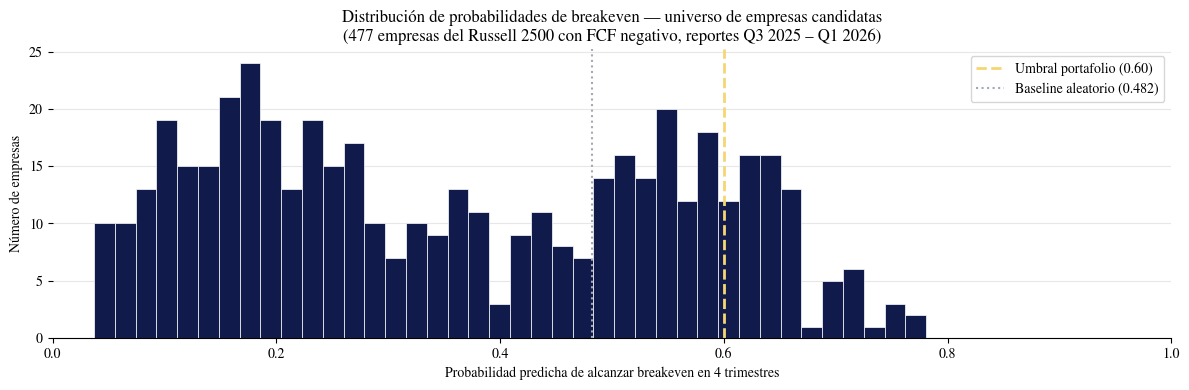

In [23]:
# Predicciones del ensemble
prob_rf   = rf_final.predict_proba(df_candidatas[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_candidatas[features_con_momentum].values)[:, 1]
df_candidatas["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Distribución de probabilidades de breakeven:")
print(df_candidatas["prob_breakeven"].describe().round(3).to_string())
print(f"\nEmpresas por umbral de probabilidad:")
for umbral in [0.50, 0.60, 0.70, 0.80]:
    n = (df_candidatas["prob_breakeven"] >= umbral).sum()
    print(f"  ≥ {umbral:.2f}: {n:>3} empresas ({n/len(df_candidatas)*100:.1f}%) — "
          f"el modelo predice con {'alta' if umbral >= 0.70 else 'moderada'} confianza")

# Gráfico — distribución de probabilidades
fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax)
ax.hist(df_candidatas["prob_breakeven"], bins=40,
        color=juan_colors[0], edgecolor="white", linewidth=0.5)
ax.axvline(0.60, color=juan_colors[5], linewidth=2,
           linestyle="--", label="Umbral portafolio (0.60)")
ax.axvline(0.482, color=juan_colors[2], linewidth=1.5,
           linestyle=":", label="Baseline aleatorio (0.482)")
ax.set_title("Distribución de probabilidades de breakeven — universo de empresas candidatas\n"
             f"({len(df_candidatas):,} empresas del Russell 2500 con FCF negativo, reportes Q3 2025 – Q1 2026)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlabel("Probabilidad predicha de alcanzar breakeven en 4 trimestres", fontfamily=FUENTE)
ax.set_ylabel("Número de empresas", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 5. Construcción del portafolio

Se aplican los tres criterios de selección:
1. **Probabilidad ≥ 0.60** — umbral de confianza mínima
2. **Máximo 3 empresas por sector** — diversificación sectorial
3. **Ordenadas por probabilidad descendente** — las mejores oportunidades primero

Para cada empresa se calculan los valores SHAP del ensemble, que explican cuáles variables empujan la predicción hacia el breakeven y cuáles la frenan.

In [24]:
UMBRAL         = 0.60
MAX_POR_SECTOR = 3

df_portafolio = (
    df_candidatas[df_candidatas["prob_breakeven"] >= UMBRAL]
    .sort_values("prob_breakeven", ascending=False)
    .groupby("sector", observed=True)
    .head(MAX_POR_SECTOR)
    .sort_values("prob_breakeven", ascending=False)
    .reset_index(drop=True)
)

# Calcular SHAP del ensemble para las empresas del portafolio
X_rf_port   = rf_final.named_steps["imputer"].transform(
    df_portafolio[features_con_momentum].values)
X_lgbm_port = lgbm_final.named_steps["imputer"].transform(
    df_portafolio[features_con_momentum].values)

shap_rf_port   = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf_port)
shap_lgbm_port = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm_port)

sv_rf_port   = shap_rf_port[1] if isinstance(shap_rf_port, list) else shap_rf_port[:, :, 1]
sv_lgbm_port = shap_lgbm_port[1] if isinstance(shap_lgbm_port, list) else shap_lgbm_port
sv_port      = (sv_rf_port + sv_lgbm_port) / 2

# Extraer top 3 razones a favor y en contra por empresa
def top3_favor(shap_row):
    s = pd.Series(shap_row, index=features_con_momentum)
    top = s[s > 0].nlargest(3)
    return ", ".join([f"{v} (+{x:.3f})" for v, x in top.items()]) if len(top) > 0 else "—"

def top3_contra(shap_row):
    s = pd.Series(shap_row, index=features_con_momentum)
    top = s[s < 0].nsmallest(3)
    return ", ".join([f"{v} ({x:.3f})" for v, x in top.items()]) if len(top) > 0 else "—"

df_portafolio["razones_favor"]   = [top3_favor(sv_port[i])  for i in range(len(df_portafolio))]
df_portafolio["razones_contra"]  = [top3_contra(sv_port[i]) for i in range(len(df_portafolio))]

print(f"Portafolio construido:")
print(f"  Empresas seleccionadas: {len(df_portafolio)}")
print(f"  Sectores representados: {df_portafolio['sector'].nunique()}")
print(f"  Probabilidad media:     {df_portafolio['prob_breakeven'].mean():.3f}")
print(f"  Probabilidad mínima:    {df_portafolio['prob_breakeven'].min():.3f}")
print(f"  Probabilidad máxima:    {df_portafolio['prob_breakeven'].max():.3f}")

Portafolio construido:
  Empresas seleccionadas: 70
  Sectores representados: 60
  Probabilidad media:     0.657
  Probabilidad mínima:    0.600
  Probabilidad máxima:    0.781


## 6. Visualizaciones del portafolio

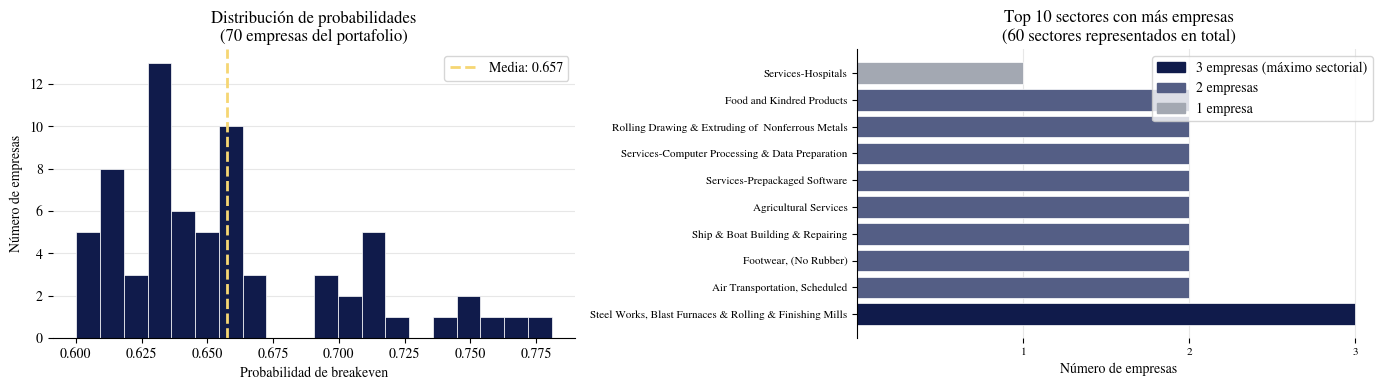

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de probabilidades
estilo_ax(axes[0])
axes[0].hist(df_portafolio["prob_breakeven"], bins=20,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].axvline(df_portafolio["prob_breakeven"].mean(),
                color=juan_colors[5], linewidth=2, linestyle="--",
                label=f"Media: {df_portafolio['prob_breakeven'].mean():.3f}")
axes[0].set_title(f"Distribución de probabilidades\n({len(df_portafolio)} empresas del portafolio)",
                  fontfamily=FUENTE, fontsize=12)
axes[0].set_xlabel("Probabilidad de breakeven", fontfamily=FUENTE)
axes[0].set_ylabel("Número de empresas", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE})

# Top sectores con más empresas
estilo_ax(axes[1], "horizontal")
conteo_sector = df_portafolio["sector"].value_counts().head(10)
colores_sector = [juan_colors[0] if v == 3 else
                  juan_colors[1] if v == 2 else
                  juan_colors[2] for v in conteo_sector.values]
axes[1].barh(conteo_sector.index, conteo_sector.values,
             color=colores_sector, edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Top 10 sectores con más empresas\n"
                  f"({df_portafolio['sector'].nunique()} sectores representados en total)",
                  fontfamily=FUENTE, fontsize=12)
axes[1].set_xlabel("Número de empresas", fontfamily=FUENTE)
axes[1].set_xticks([1, 2, 3])
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

p1 = mpatches.Patch(color=juan_colors[0], label="3 empresas (máximo sectorial)")
p2 = mpatches.Patch(color=juan_colors[1], label="2 empresas")
p3 = mpatches.Patch(color=juan_colors[2], label="1 empresa")
axes[1].legend(handles=[p1, p2, p3], prop={"family": FUENTE}, fontsize=8)

plt.tight_layout()
plt.show()

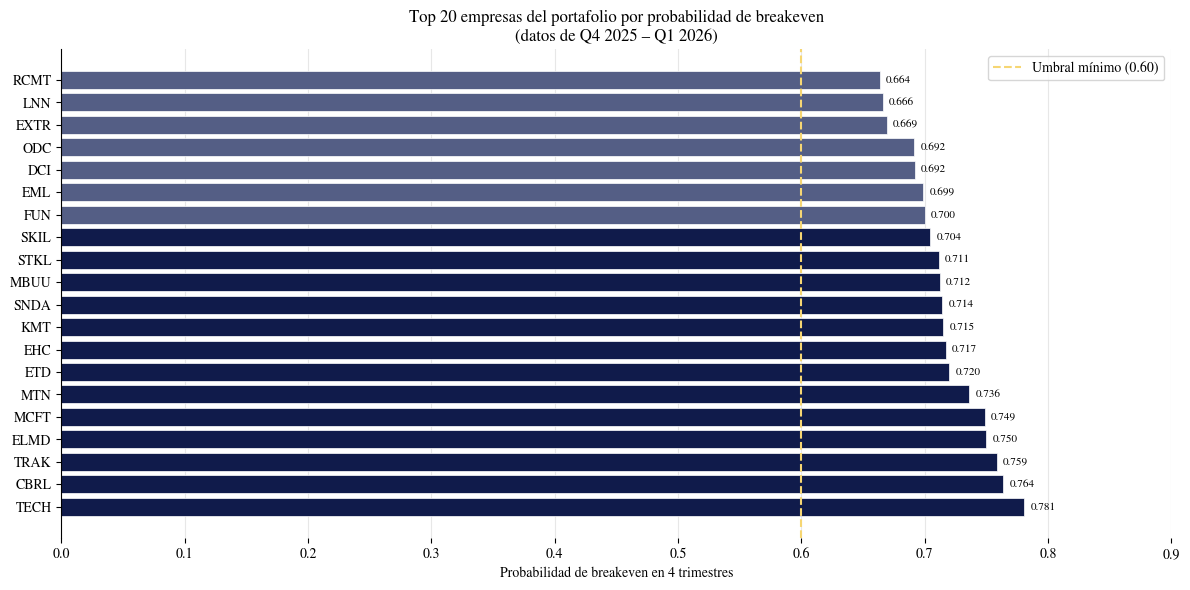

In [26]:
# 6.2 Top 20 empresas — gráfico de probabilidades
top20 = df_portafolio.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
estilo_ax(ax, "horizontal")

colores_bar = [
    juan_colors[0] if p >= 0.70 else
    juan_colors[1] if p >= 0.65 else
    juan_colors[2] for p in top20["prob_breakeven"]
]
bars = ax.barh(top20["ticker"], top20["prob_breakeven"],
               color=colores_bar, edgecolor="white", linewidth=0.5)
ax.axvline(0.60, color=juan_colors[5], linewidth=1.5,
           linestyle="--", label="Umbral mínimo (0.60)")

for bar, prob, sector in zip(bars, top20["prob_breakeven"], top20["sector"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{prob:.3f}", va="center", fontfamily=FUENTE, fontsize=8)

ax.set_xlabel("Probabilidad de breakeven en 4 trimestres", fontfamily=FUENTE)
ax.set_title("Top 20 empresas del portafolio por probabilidad de breakeven\n"
             "(datos de Q4 2025 – Q1 2026)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlim(0, 0.90)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

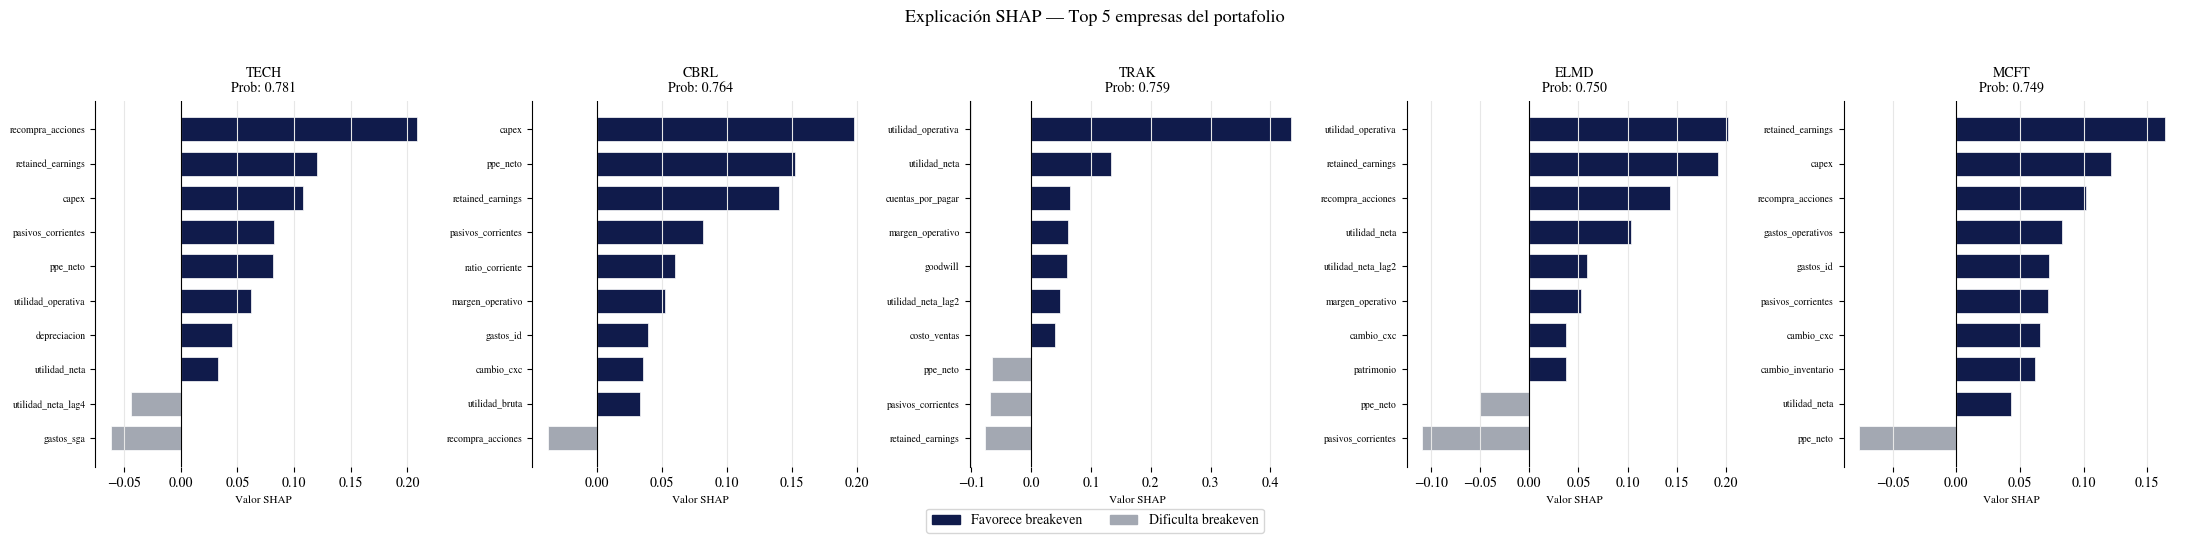

In [27]:
# 6.3 SHAP waterfall para las top 5 empresas
top5 = df_portafolio.head(5)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (_, empresa) in zip(axes, top5.iterrows()):
    idx       = empresa.name
    shap_emp  = pd.Series(sv_port[idx], index=features_con_momentum)
    top10     = shap_emp.abs().nlargest(10).index
    shap_top  = shap_emp[top10].sort_values()

    colores_wf = [juan_colors[0] if v > 0 else juan_colors[2]
                  for v in shap_top.values]
    ax.barh(range(len(shap_top)), shap_top.values,
            color=colores_wf, edgecolor="white", linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(shap_top)))
    ax.set_yticklabels(shap_top.index, fontfamily=FUENTE, fontsize=7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{empresa['ticker']}\nProb: {empresa['prob_breakeven']:.3f}",
                 fontfamily=FUENTE, fontsize=10)
    ax.set_xlabel("Valor SHAP", fontfamily=FUENTE, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_pos = mpatches.Patch(color=juan_colors[0], label="Favorece breakeven")
patch_neg = mpatches.Patch(color=juan_colors[2], label="Dificulta breakeven")
fig.legend(handles=[patch_pos, patch_neg], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("Explicación SHAP — Top 5 empresas del portafolio",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Portafolio completo

La siguiente tabla muestra todas las empresas seleccionadas con sus variables financieras clave y la explicación del modelo. Las columnas **razones a favor** y **razones en contra** muestran las 3 variables SHAP con mayor impacto positivo y negativo respectivamente, con el valor de su contribución entre paréntesis.

**Cómo leer la tabla:**
- `prob_breakeven`: probabilidad de alcanzar FCF positivo en los próximos 4 trimestres
- `end`: fecha del último reporte financiero disponible
- `fcf_operativo`: quema de caja trimestral actual en USD
- `burn_rate`: valor absoluto del FCF operativo — cuánto efectivo consume por trimestre
- `retained_earnings`: ganancias acumuladas históricas — positivo indica empresa con historial rentable

In [28]:
# Tabla completa del portafolio
cols_display = [
    "ticker", "sector", "prob_breakeven", "end",
    "fcf_operativo", "burn_rate", "retained_earnings",
    "razones_favor", "razones_contra"
]

df_display = df_portafolio[cols_display].copy()
df_display["prob_breakeven"]   = df_display["prob_breakeven"].round(3)
df_display["fcf_operativo"]    = (df_display["fcf_operativo"] / 1e6).round(1).astype(str) + "M"
df_display["burn_rate"]        = (df_display["burn_rate"] / 1e6).round(1).astype(str) + "M"
df_display["retained_earnings"]= (df_display["retained_earnings"] / 1e6).round(0).astype(str) + "M"
df_display["end"]              = df_display["end"].dt.to_period("Q").astype(str)

df_display.columns = [
    "Ticker", "Sector", "Prob. Breakeven", "Último reporte",
    "FCF operativo", "Burn rate", "Retained earnings",
    "Razones a favor (SHAP)", "Razones en contra (SHAP)"
]

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 100)
print(f"Portafolio final — {len(df_display)} empresas en {df_portafolio['sector'].nunique()} sectores")
print(f"Horizonte de predicción: 4 trimestres (~12 meses desde el último reporte)")
print()
display(df_display)

Portafolio final — 70 empresas en 60 sectores
Horizonte de predicción: 4 trimestres (~12 meses desde el último reporte)



,Ticker,Sector,Prob. Breakeven,Último reporte,FCF operativo,Burn rate,Retained earnings,Razones a favor (SHAP),Razones en contra (SHAP)
0,TECH,"Biological Products, (No Diagnostic Substances)",0.781,2025Q4,-38.2M,38.2M,1107.0M,"recompra_acciones (+0.208), retained_earnings (+0.120), capex (+0.108)","gastos_sga (-0.062), utilidad_neta_lag4 (-0.044), gastos_operativos (-0.019)"
1,CBRL,Retail-Eating Places,0.764,2026Q1,-95.9M,95.9M,416.0M,"capex (+0.197), ppe_neto (+0.152), retained_earnings (+0.140)","recompra_acciones (-0.038), fcf_operativo_lag2 (-0.026), utilidad_neta (-0.021)"
2,TRAK,Services-Computer Processing & Data Preparation,0.759,2025Q4,-1.6M,1.6M,-10.0M,"utilidad_operativa (+0.434), utilidad_neta (+0.133), cuentas_por_pagar (+0.064)","retained_earnings (-0.078), pasivos_corrientes (-0.068), ppe_neto (-0.066)"
3,ELMD,Electromedical & Electrotherapeutic Apparatus,0.750,2025Q4,-2.3M,2.3M,22.0M,"utilidad_operativa (+0.202), retained_earnings (+0.191), recompra_acciones (...","pasivos_corrientes (-0.109), ppe_neto (-0.050), goodwill (-0.030)"
4,MCFT,Ship & Boat Building & Repairing,0.749,2025Q4,-26.8M,26.8M,137.0M,"retained_earnings (+0.164), capex (+0.122), recompra_acciones (+0.102)","ppe_neto (-0.077), burn_rate_cambio_pct (-0.043), activos_intangibles (-0.023)"
5,MTN,Services-Miscellaneous Amusement & Recreation,0.736,2026Q1,-33.3M,33.3M,583.0M,"retained_earnings (+0.147), ppe_neto (+0.131), ingresos_diferidos (+0.082)","utilidad_neta_lag2 (-0.067), caja (-0.043), caja_lag4 (-0.043)"
6,ETD,"Wood Household Furniture, (No Upholstered)",0.720,2025Q4,-11.7M,11.7M,781.0M,"capex (+0.141), retained_earnings (+0.099), ppe_neto (+0.094)","gastos_sga (-0.052), recompra_acciones (-0.048), fcf_operativo_lag2 (-0.022)"
7,EHC,Services-Hospitals,0.717,2025Q4,-28.9M,28.9M,-1921.0M,"ppe_neto (+0.109), utilidad_operativa (+0.106), pasivos_corrientes (+0.104)","capex (-0.103), retained_earnings (-0.045), stock_based_comp (-0.033)"
8,KMT,"Machine Tools, Metal Cutting Types",0.715,2025Q4,-28.3M,28.3M,1229.0M,"recompra_acciones (+0.277), retained_earnings (+0.112), ppe_neto (+0.093)","cambio_inventario (-0.095), gastos_sga (-0.047), capex (-0.042)"
9,SNDA,Services-Nursing & Personal Care Facilities,0.714,2025Q4,-0.4M,0.4M,-461.0M,"utilidad_operativa (+0.165), recompra_acciones (+0.146), ppe_neto (+0.118)","retained_earnings (-0.109), capex (-0.097), utilidad_neta (-0.027)"


In [29]:
# Guardar portafolio en CSV
ruta_portafolio = "../salidas/portafolio_recomendado.csv"
df_portafolio[cols_display].to_csv(ruta_portafolio, index=False)
print(f"Portafolio guardado: {ruta_portafolio}")
print(f"\nResumen final:")
print(f"  Empresas en portafolio:     {len(df_portafolio)}")
print(f"  Sectores representados:     {df_portafolio['sector'].nunique()}")
print(f"  Probabilidad media:         {df_portafolio['prob_breakeven'].mean():.3f}")
print(f"  Reportes Q4 2025 o más rec: {(df_portafolio['end'] >= '2024-10-01').sum()}")
print(f"  Horizonte de predicción:    4 trimestres (~12 meses)")

Portafolio guardado: ../salidas/portafolio_recomendado.csv

Resumen final:
  Empresas en portafolio:     70
  Sectores representados:     60
  Probabilidad media:         0.657
  Reportes Q4 2025 o más rec: 70
  Horizonte de predicción:    4 trimestres (~12 meses)
